#  Symptom Checker with Medical Text Classification

## Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, GRU, Bidirectional,
    Input, GlobalAveragePooling1D, Layer, MultiHeadAttention, 
    LayerNormalization, Concatenate, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import re
import string
import nltk
import seaborn as sns
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import json
from collections import Counter
import pickle
import os
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

2025-05-05 21:23:20.596465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746480200.772221      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746480200.821878      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load dataset

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Loading dataset...")
# Load dataset from Hugging Face
dataset = load_dataset("mohammad2928git/complete_medical_symptom_dataset")
df = pd.DataFrame(dataset['train'][:50000])


Loading dataset...


README.md:   0%|          | 0.00/776 [00:00<?, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/81.3M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/82.7M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/83.1M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/76.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1300022 [00:00<?, ? examples/s]

In [3]:
columns_to_keep = ['symptoms', 'lebel_text']
df = df[columns_to_keep]

# Basic data exploration
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns}")
print("\nSample data:")
print(df.head())

Dataset shape: (50000, 2)
Columns: Index(['symptoms', 'lebel_text'], dtype='object')

Sample data:
                                            symptoms  \
0  [migraines headaches,  can't sleep,  whole bod...   
1  [asthma wheezing breathing problems,  fevers, ...   
2  [signs symptoms primary ovarian insufficiency ...   
3  [cough, high fever, breathlessness, family his...   
4  [chills, vomiting, high fever, sweating, heada...   

                    lebel_text  
0              [drug reaction]  
1                    [allergy]  
2  [premature ovarian failure]  
3           [bronchial asthma]  
4                    [malaria]  


In [4]:
# Create a text field by combining symptoms
df['symptoms_text'] = df['symptoms'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
df.dropna(subset=['symptoms'], inplace=True)

In [5]:
df.columns = ['symptoms', 'disease', 'symptoms_text']
print(df.columns)

Index(['symptoms', 'disease', 'symptoms_text'], dtype='object')


In [6]:
null_counts = df.isnull().sum()
null_counts

symptoms         0
disease          0
symptoms_text    0
dtype: int64

In [8]:
# Create a cleaned version: list of symptoms
df['symptom_list'] = df['symptoms'].apply(
    lambda x: [s.strip() for s in x] if isinstance(x, list)
    else [s.strip() for s in str(x).split(',')]
)

# Create a combined text field for NLP
df['symptoms_text'] = df['symptom_list'].apply(lambda x: ' '.join(x))

# Count all symptoms
all_symptoms = []
for symptom_list in df['symptom_list']:
    all_symptoms.extend(symptom_list)
symptom_counts = Counter(all_symptoms)
print(f"\nTotal unique symptoms: {len(symptom_counts)}")
print("\nTop 10 symptoms:")
print(pd.Series(symptom_counts).sort_values(ascending=False).head(10))



Total unique symptoms: 18434

Top 10 symptoms:
feel pain                                                             127724
characterize pain:                                                     65831
pain radiate location                                                  54110
traveled country last 4 weeks                                          42557
intense pain                                                           31822
precisely pain located                                                 31822
fast pain                                                              31822
pain reason consulting                                                 31386
affected region located                                                24088
experiencing shortness breath difficulty breathing significant way     16351
dtype: int64


In [11]:
# Check class distribution
disease_counts = df['disease'].value_counts()
print("\nDisease distribution (top 10):")
print(disease_counts.head(10))
print(f"Total unique diseases: {len(disease_counts)}")
df['disease'] = df['disease'].apply(lambda x: x[0] if isinstance(x, list) else x)
# Handle class imbalance: filter out diseases with very few samples
MIN_SAMPLES = 5  # Only keep diseases with at least 5 samples
common_diseases = disease_counts[disease_counts >= MIN_SAMPLES].index
df_reduced = df[df['disease'].isin(common_diseases)]
print(f"\nAfter filtering rare diseases: {df_reduced.shape[0]} samples, {len(df_reduced['disease'].unique())} diseases")



Disease distribution (top 10):
disease
bronchitis                  5173
urti                        2515
possible nstemi / stemi     2337
anemia                      2234
viral pharyngitis           1992
unstable angina             1544
allergic sinusitis          1359
pulmonary embolism          1319
localized edema             1222
acute dystonic reactions    1188
Name: count, dtype: int64
Total unique diseases: 1375

After filtering rare diseases: 48592 samples, 90 diseases


## Preprocessing step

In [12]:
# Text Preprocessing Function
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """Enhanced text preprocessing function"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatization
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

In [13]:
# Apply preprocessing
print("Preprocessing text data...")
df_reduced['processed_symptoms'] = df_reduced['symptoms_text'].apply(preprocess_text)


Preprocessing text data...


In [14]:
# Convert to numeric class labels using LabelEncoder
print("Encoding disease labels...")
label_encoder = LabelEncoder()
df_reduced['disease_encoded'] = label_encoder.fit_transform(df_reduced['disease'])
num_classes = len(label_encoder.classes_)
print(f"Number of disease classes after filtering: {num_classes}")

# Create one-hot representation of symptoms for better performance
print("Creating one-hot symptom features...")
# Get top symptoms (features)
TOP_N_SYMPTOMS = 500
top_symptoms = [symptom for symptom, _ in symptom_counts.most_common(TOP_N_SYMPTOMS)]

# Create one-hot feature matrix
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(vocabulary=top_symptoms, binary=True)
X_bow = vectorizer.fit_transform(df_reduced['symptoms_text']).toarray()
print(f"One-hot feature shape: {X_bow.shape}")


Encoding disease labels...
Number of disease classes after filtering: 90
Creating one-hot symptom features...
One-hot feature shape: (48592, 500)


In [15]:
# Create y labels
y_encoded = df_reduced['disease_encoded'].values
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Create train/val/test splits
X_temp, X_test, y_temp, y_test = train_test_split(
    X_bow, y_categorical, test_size=0.1, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp.argmax(axis=1)
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")


Train set: (34985, 500), (34985, 90)
Validation set: (8747, 500), (8747, 90)
Test set: (4860, 500), (4860, 90)


## Model building

In [16]:
# Build a simpler model first to establish a baseline
def build_baseline_model(input_dim, num_classes):
    """Create a simpler neural network model for baseline performance"""
    model = Sequential([
        Dense(512, input_dim=input_dim, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


In [17]:
# Create the model
print("Building baseline model...")
baseline_model = build_baseline_model(X_bow.shape[1], num_classes)
baseline_model.summary()

Building baseline model...


I0000 00:00:1746480437.978410      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         256,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 90)                  │          11,610 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 432,346 (1.65 MB)

 Trainable params: 432,346 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [18]:
# Setup callbacks for training
os.makedirs('models', exist_ok=True)
checkpoint = ModelCheckpoint(
    'models/best_baseline_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the baseline model
print("Training baseline model...")
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Evaluate the baseline model
baseline_loss, baseline_acc = baseline_model.evaluate(X_test, y_test)
print(f"Baseline model test accuracy: {baseline_acc:.4f}")


Training baseline model...
Epoch 1/15


I0000 00:00:1746480441.446982     114 service.cc:148] XLA service 0x7ad6d40d23b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746480441.447440     114 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746480441.697292     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


 97/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0799 - loss: 4.3137

I0000 00:00:1746480443.604688     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2987 - loss: 3.0861
Epoch 1: val_accuracy improved from -inf to 0.73911, saving model to models/best_baseline_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2991 - loss: 3.0845 - val_accuracy: 0.7391 - val_loss: 1.0096 - learning_rate: 3.0000e-04
Epoch 2/15
536/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6819 - loss: 1.1451
Epoch 2: val_accuracy improved from 0.73911 to 0.77787, saving model to models/best_baseline_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6824 - loss: 1.1433 - val_accuracy: 0.7779 - val_loss: 0.7571 - learning_rate: 3.0000e-04
Epoch 3/15
544/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7367 - loss: 0.9131
Epoch 3: val_accuracy improved from 0.77787 to 0.78335, saving model to models/best_baseline_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7368 - loss: 0.9129 - val_accuracy: 0.7834 - val_loss: 0.6940 - learning_rate: 3.0000e-04
Epoch 

In [19]:
# Process text for sequence model
print("Preparing sequence features for advanced model...")
MAX_FEATURES = 5000
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(df_reduced['processed_symptoms'])

# Create sequence features
X_sequences = tokenizer.texts_to_sequences(df_reduced['processed_symptoms'])
max_len = 20  # Based on sequence length distribution
X_padded = pad_sequences(X_sequences, maxlen=max_len, padding='post')

# Split sequence data
X_seq_train, X_seq_test, _, _ = train_test_split(
    X_padded, y_categorical, test_size=0.1, random_state=42, stratify=y_encoded
)
X_seq_train, X_seq_val, _, _ = train_test_split(
    X_seq_train, y_temp, test_size=0.2, random_state=42, stratify=y_temp.argmax(axis=1)
)


Preparing sequence features for advanced model...


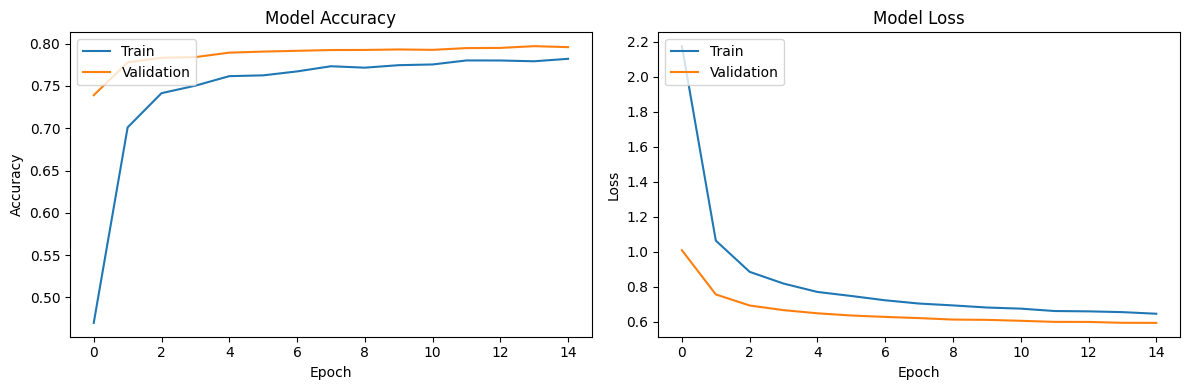

In [28]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['accuracy'])
plt.plot(baseline_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['loss'])
plt.plot(baseline_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Model improvement

In [20]:
# Advanced model with multiple inputs
def build_advanced_model(bow_input_dim, seq_input_dim, max_len, num_classes):
    """Create a model that uses both bag-of-words and sequence features"""
    
    # Bag-of-words input branch
    bow_input = Input(shape=(bow_input_dim,), name='bow_input')
    bow_branch = Dense(256, activation='relu')(bow_input)
    bow_branch = Dropout(0.3)(bow_branch)
    
    # Sequence input branch
    seq_input = Input(shape=(max_len,), name='seq_input')
    embedding = Embedding(input_dim=MAX_FEATURES, output_dim=100)(seq_input)
    seq_branch = Bidirectional(LSTM(64, return_sequences=True))(embedding)
    seq_branch = GlobalAveragePooling1D()(seq_branch)
    seq_branch = Dropout(0.3)(seq_branch)
    
    # Concatenate branches
    concatenated = Concatenate()([bow_branch, seq_branch])
    
    # Common layers
    x = Dense(128, activation='relu')(concatenated)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # Create model
    model = Model(inputs=[bow_input, seq_input], outputs=outputs)
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## Training

In [21]:
# Create the advanced model
print("Building advanced model...")
advanced_model = build_advanced_model(X_bow.shape[1], MAX_FEATURES, max_len, num_classes)
advanced_model.summary()

# Setup callbacks for advanced model
advanced_checkpoint = ModelCheckpoint(
    'models/best_advanced_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train the advanced model
print("Training advanced model...")
advanced_history = advanced_model.fit(
    {'bow_input': X_train, 'seq_input': X_seq_train},
    y_train,
    validation_data=({'bow_input': X_val, 'seq_input': X_seq_val}, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, advanced_checkpoint]
)


Building advanced model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)    │ (None, 20)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 20, 100)        │        500,000 │ seq_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bow_input (InputLayer)    │ (None, 500)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 20, 128)        │         84,480 │ embedding[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 256)            │        128,256 │ bow_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d  │ (None, 128)            │              0 │ bidirectional[0][0]    │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 256)            │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 128)            │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 384)            │              0 │ dropout_3[0][0],       │
│                           │                        │                │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │         49,280 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 90)             │         11,610 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 773,626 (2.95 MB)

 Trainable params: 773,626 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

Training advanced model...
Epoch 1/15
542/547 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3006 - loss: 3.1078
Epoch 1: val_accuracy improved from -inf to 0.82383, saving model to models/best_advanced_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.3028 - loss: 3.0970 - val_accuracy: 0.8238 - val_loss: 0.8529 - learning_rate: 3.0000e-04
Epoch 2/15
542/547 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7841 - loss: 0.8750
Epoch 2: val_accuracy improved from 0.82383 to 0.86029, saving model to models/best_advanced_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7843 - loss: 0.8739 - val_accuracy: 0.8603 - val_loss: 0.5232 - learning_rate: 3.0000e-04
Epoch 3/15
542/547 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8342 - loss: 0.6080
Epoch 3: val_accuracy improved from 0.86029 to 0.86841, saving model to models/best_advanced_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8343 - loss: 0.6076 - val_accuracy: 0.8684 - val_loss: 0

## Evaluation

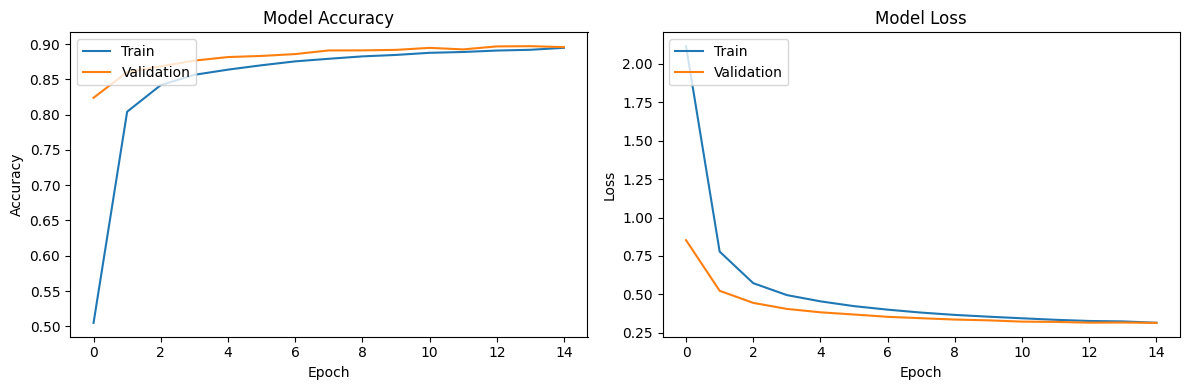

In [29]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(advanced_history.history['accuracy'])
plt.plot(advanced_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(advanced_history.history['loss'])
plt.plot(advanced_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
# Evaluate the advanced model
advanced_loss, advanced_acc = advanced_model.evaluate(
    {'bow_input': X_test, 'seq_input': X_seq_test},
    y_test
)
print(f"Advanced model test accuracy: {advanced_acc:.4f}")

# Save the final model and preprocessing components
advanced_model.save("models/final_advanced_model.h5")

# Save the tokenizer and vectorizer for later use
with open('models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
with open('models/vectorizer.pickle', 'wb') as handle:
    pickle.dump(vectorizer, handle, protocol=pickle.HIGHEST_PROTOCOL)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8915 - loss: 0.3241
Advanced model test accuracy: 0.8893


In [23]:
import json

# Ensure consistent label encoding
unique_diseases = sorted(df_reduced['disease'].unique())
disease_mapping = {str(i): disease for i, disease in enumerate(unique_diseases)}

# Save to JSON
with open('/kaggle/working/models/disease_mapping.json', 'w') as f:
    json.dump(disease_mapping, f)


## Make prediction

In [24]:
# Function to predict disease from symptoms
def predict_disease(symptoms_text, model_type='advanced'):
    """Predict disease based on symptoms text"""
    # Load necessary components
    with open('/kaggle/working/models/tokenizer.pickle', 'rb') as handle:
        tokenizer = pickle.load(handle)
    
    with open('/kaggle/working/models/vectorizer.pickle', 'rb') as handle:
        vectorizer = pickle.load(handle)
    
    with open('/kaggle/working/models/disease_mapping.json', 'r') as f:
        disease_mapping = json.load(f)
    
    if model_type == 'advanced':
        model = tf.keras.models.load_model('/kaggle/working/models/best_advanced_model.keras')
    else:
        model = tf.keras.models.load_model('models/best_baseline_model.keras')
    
    # Preprocess the input text
    processed_text = preprocess_text(symptoms_text)
    
    if model_type == 'advanced':
        # Create both feature types
        bow_features = vectorizer.transform([symptoms_text]).toarray()
        seq_features = pad_sequences(tokenizer.texts_to_sequences([processed_text]), maxlen=20, padding='post')
        
        # Get prediction probabilities
        pred_probs = model.predict({'bow_input': bow_features, 'seq_input': seq_features})[0]
    else:
        # Just use BOW features for baseline model
        bow_features = vectorizer.transform([symptoms_text]).toarray()
        pred_probs = model.predict(bow_features)[0]
    
    # Get top 3 predictions
    top_indices = pred_probs.argsort()[-3:][::-1]
    top_probs = pred_probs[top_indices]
    
    # Convert indices to disease names
    top_diseases = [disease_mapping[str(idx)] for idx in top_indices]
    
    # Return results
    return list(zip(top_diseases, top_probs))

print("Training and evaluation complete. Results saved in 'models' directory.")


Training and evaluation complete. Results saved in 'models' directory.


In [25]:
# Example symptoms
symptoms_text = "I have a runny nose, sneezing, sore throat, and nasal congestion."

# Call the prediction function
predictions = predict_disease(symptoms_text, model_type='advanced')

# Print the predictions
for disease, prob in predictions:
    print(f"Disease: {disease}, Probability: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
Disease: gastroesophageal reflux disease, Probability: 0.7743
Disease: urti, Probability: 0.0822
Disease: allergy, Probability: 0.0487


In [26]:
# Example symptoms
symptoms_text = "I have a cough, shortness of breath, and wheezing"

# Call the prediction function
predictions = predict_disease(symptoms_text, model_type='advanced')

# Print the predictions
for disease, prob in predictions:
    print(f"Disease: {disease}, Probability: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Disease: bronchial asthma, Probability: 0.6588
Disease: bronchitis, Probability: 0.2011
Disease: diabetes, Probability: 0.0762


In [27]:
# Example multiple symptoms
symptoms_list = [
    "I have a sore throat, fever, and difficulty swallowing.",
    "I have a cough, shortness of breath, and wheezing.",
    "I feel feverish, have chills, a sore throat, and muscle aches.",
    "I have chest pain, palpitations, and lightheadedness.",
    "I have frequent heartburn, stomach bloating, and indigestion.",
    "I am feeling dizzy, lightheaded, and have a headache that won't go away."
]

# Loop through the list of symptoms and get predictions
for symptoms_text in symptoms_list:
    print(f"Symptoms: {symptoms_text}")
    
    # Call the prediction function
    predictions = predict_disease(symptoms_text, model_type='advanced')
    
    # Print the predictions for each symptom set
    for disease, prob in predictions:
        print(f"  Disease: {disease}, Probability: {prob:.4f}")
    print("\n" + "-"*50 + "\n")


Symptoms: I have a sore throat, fever, and difficulty swallowing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
  Disease: gastroesophageal reflux disease, Probability: 0.3835
  Disease: impetigo, Probability: 0.2451
  Disease: diabetes, Probability: 0.1189

--------------------------------------------------

Symptoms: I have a cough, shortness of breath, and wheezing.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
  Disease: bronchial asthma, Probability: 0.6588
  Disease: bronchitis, Probability: 0.2011
  Disease: diabetes, Probability: 0.0762

--------------------------------------------------

Symptoms: I feel feverish, have chills, a sore throat, and muscle aches.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
  Disease: gastroesophageal reflux disease, Probability: 0.5264
  Disease: allergy, Probability: 0.1793
  Disease: diabetes, Probability: 0.1292

--------------------------------------------------

Symptoms: I have chest pain, palpitations, and lightheadedness.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/st